In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("E-Commerce Analysis").getOrCreate()
spark
# https://github.com/NaelAqel/db_gen.git

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# importing necessary functions
from pyspark.sql.functions import sum, avg, count,desc

🧩 Beginner Level (Data Loading & Basics)

Load all tables
Load all five tables (customers, orders, order_items, products, product_reviews) as PySpark DataFrames from CSV files.

Show data summary
Print the schema and show 5 rows of each DataFrame.

Count total records
Find total number of records in each table.

Select specific columns
Select only name, email, and country columns from customers DataFrame.

Filter customers by country
Show all customers from "India".



In [6]:
#load all tables
customers_df = spark.read.csv("Datasets/csv/customers.csv", header=True, inferSchema=True)
orders_df = spark.read.csv("Datasets/csv/orders.csv", header=True, inferSchema=True)
products_df = spark.read.csv("Datasets/csv/products.csv", header=True, inferSchema=True)
order_items_df = spark.read.csv("Datasets/csv/order_items.csv", header=True, inferSchema=True)
product_reviews_df = spark.read.csv("Datasets/csv/product_reviews.csv", header=True, inferSchema=True)


In [7]:

#show sample data from each table
print("table samples:")
print("customers:")
customers_df.show(5)
print("orders:")
orders_df.show(5)
print("products:")
products_df.show(5)
print("order_items:")
order_items_df.show(5)
print("product_reviews:")
product_reviews_df.show(5)

table samples:
customers:
+-----------+---------------+--------------------+------+-----------+----------+
|customer_id|           name|               email|gender|signup_date|   country|
+-----------+---------------+--------------------+------+-----------+----------+
|          1|   Allison Hill|donaldgarcia@exam...| Other| 2025-02-15|     Benin|
|          2|   Amanda Davis|williamjohnson@ex...|  Male| 2024-03-30|   Reunion|
|          3|Connie Lawrence|blakeerik@example...|  Male| 2022-05-13|Cape Verde|
|          4| Phillip Garcia|  wdavis@example.net| Other| 2021-12-26|     Aruba|
|          5|Kimberly Dudley| smiller@example.net|Female| 2023-10-04|   Tokelau|
+-----------+---------------+--------------------+------+-----------+----------+
only showing top 5 rows
orders:
+--------+-----------+----------+------------+--------------+----------------+
|order_id|customer_id|order_date|total_amount|payment_method|shipping_country|
+--------+-----------+----------+------------+---------

In [8]:
#print schema of each table
print("table schemas:")
print("customers schema:")
customers_df.printSchema()
print("orders schema:")
orders_df.printSchema()
print("products schema:")
products_df.printSchema()
print("order_items schema:")
order_items_df.printSchema()
print("product_reviews schema:")
product_reviews_df.printSchema()

table schemas:
customers schema:
root
 |-- customer_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- signup_date: date (nullable = true)
 |-- country: string (nullable = true)

orders schema:
root
 |-- order_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- shipping_country: string (nullable = true)

products schema:
root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- price: double (nullable = true)
 |-- stock_quantity: integer (nullable = true)
 |-- brand: string (nullable = true)

order_items schema:
root
 |-- order_item_id: integer (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- quantity: i

In [9]:

#count rows in each table
print("table row counts:")
print(f"customers: {customers_df.count()}")
print(f"orders: {orders_df.count()}")
print(f"products: {products_df.count()}")
print(f"order_items: {order_items_df.count()}")
print(f"product_reviews: {product_reviews_df.count()}")

table row counts:
customers: 2000000
orders: 8000000
products: 20000
order_items: 20000000
product_reviews: 4000000


In [10]:

#Select specific columns
customers_df.select("customer_id", "name", "email").show(5)
orders_df.select("order_id", "customer_id", "order_date", "total_amount").show(5)
products_df.select("product_id", "product_name", "category", "price").show(5)
order_items_df.select("order_item_id", "order_id", "product_id", "quantity").show(5)
product_reviews_df.select("review_id", "product_id", "customer_id", "rating", "review_date").show(5) 

+-----------+---------------+--------------------+
|customer_id|           name|               email|
+-----------+---------------+--------------------+
|          1|   Allison Hill|donaldgarcia@exam...|
|          2|   Amanda Davis|williamjohnson@ex...|
|          3|Connie Lawrence|blakeerik@example...|
|          4| Phillip Garcia|  wdavis@example.net|
|          5|Kimberly Dudley| smiller@example.net|
+-----------+---------------+--------------------+
only showing top 5 rows
+--------+-----------+----------+------------+
|order_id|customer_id|order_date|total_amount|
+--------+-----------+----------+------------+
|       1|     331090|2025-05-12|      774.46|
|       2|     208473|2022-12-31|       757.8|
|       3|     847096|2021-09-19|     2355.87|
|       4|    1919911|2024-10-21|      776.77|
|       5|     281685|2024-10-26|         0.0|
+--------+-----------+----------+------------+
only showing top 5 rows
+----------+---------------+--------+------+
|product_id|   product_na

In [11]:

#Show rows, count where country is India
cust_ind=customers_df.filter(customers_df["country"] == "India")
cust_ind.show()
cust_ind.count()

+-----------+--------------------+--------------------+------+-----------+-------+
|customer_id|                name|               email|gender|signup_date|country|
+-----------+--------------------+--------------------+------+-----------+-------+
|         60|      Rebecca Ramsey|ncalhoun@example.net| Other| 2020-10-18|  India|
|        156|     Felicia Aguilar|sabrinacollins@ex...| Other| 2024-02-27|  India|
|        237|        Bobby Brandt|desireebailey@exa...|  Male| 2025-08-17|  India|
|        429|   Mitchell Griffith|kingjames@example...|  Male| 2025-04-25|  India|
|        576|       Walter Castro|williamssandra@ex...|Female| 2022-05-01|  India|
|        664|     Brittany Bowman|ortegajoseph@exam...| Other| 2022-04-24|  India|
|        691|    William Williams|  gquinn@example.org|Female| 2022-10-16|  India|
|        783|     Debbie Mcdaniel|lauren31@example.com| Other| 2022-07-02|  India|
|        881|     Amanda Griffith|ramirezrobert@exa...|  Male| 2022-03-30|  India|
|   

8271

In [13]:
# create a temporary view for SQL queries
customers_df.createOrReplaceTempView("customers")
orders_df.createOrReplaceTempView("orders")
products_df.createOrReplaceTempView("products")
order_items_df.createOrReplaceTempView("order_items")
product_reviews_df.createOrReplaceTempView("product_reviews")



In [ ]:
# Example SQL query: Top 5 customers by total order amount
top_customers = spark.sql("""
    SELECT c.customer_id, c.name, SUM(o.total_amount) as total_spent
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    GROUP BY c.customer_id, c.name
    ORDER BY total_spent DESC
    LIMIT 5
""")
top_customers.show()

+-----------+----------------+------------------+
|customer_id|            name|       total_spent|
+-----------+----------------+------------------+
|    1631919|Christine Harris|          48164.71|
|    1845030|   Shannon Young|46880.810000000005|
|    1690431|    Robert Klein|44065.280000000006|
|     279304|   Brooke Harris|          44009.77|
|    1242816|   James Collins|43428.829999999994|
+-----------+----------------+------------------+



In [12]:
#load all tables into mysql database
jdbc_url = "jdbc:mysql://localhost:3306/ecommerce_db_1_gb"
properties = {
    "user": "root",
    "password": "pdk789",
    "driver": "com.mysql.cj.jdbc.Driver"
}


In [ ]:
# dataframes to MySQL it will take time to load 1GB data
# customers_df.write.jdbc(url=jdbc_url, table="customers", mode="overwrite", properties=properties)

In [9]:

#orders_df.write.jdbc(url=jdbc_url, table="orders", mode="overwrite", properties=properties)

In [10]:

#products_df.write.jdbc(url=jdbc_url, table="products", mode="overwrite", properties=properties)


In [11]:
#order_items_df.write.jdbc(url=jdbc_url, table="order_items", mode="overwrite", properties=properties)

In [12]:

#product_reviews_df.write.jdbc(url=jdbc_url, table="product_reviews", mode="overwrite", properties=properties)

⚙️ Intermediate Level (Joins & Aggregations)

Join orders with customers
Join orders and customers to display:
order_id, name, order_date, total_amount, country.

Top 5 highest order amounts
Find top 5 orders by total_amount.

Total revenue per customer
Calculate the total amount spent by each customer using groupBy("customer_id").

Total quantity per product
Using order_items, calculate how many units of each product have been sold.

Total revenue per product
Join order_items and products and calculate total revenue = quantity * unit_price per product.


In [13]:
#Join orders with customers
cust_with_orders =customers_df.join(orders_df, customers_df.customer_id==orders_df.customer_id)
cust_with_orders.show()

+-----------+-----------------+--------------------+------+-----------+----------+--------+-----------+----------+------------+--------------+--------------------+
|customer_id|             name|               email|gender|signup_date|   country|order_id|customer_id|order_date|total_amount|payment_method|    shipping_country|
+-----------+-----------------+--------------------+------+-----------+----------+--------+-----------+----------+------------+--------------+--------------------+
|         28|        Brooke Yu|yorkcasey@example...| Other| 2024-01-15|  Dominica|  231151|         28|2025-08-15|     1161.18|   Credit Card|             Estonia|
|         28|        Brooke Yu|yorkcasey@example...| Other| 2024-01-15|  Dominica| 1156037|         28|2022-02-11|     1657.39|        PayPal|             Ecuador|
|         28|        Brooke Yu|yorkcasey@example...| Other| 2024-01-15|  Dominica| 1677315|         28|2022-03-23|     2195.45| Bank Transfer|        Burkina Faso|
|         28|   

In [14]:
#Join orders and customers to display:
#order_id, name, order_date, total_amount, country.
cust_with_orders.select('order_id','name','order_date',"total_amount","country").show(20)

+--------+-----------------+----------+------------+----------+
|order_id|             name|order_date|total_amount|   country|
+--------+-----------------+----------+------------+----------+
|  231151|        Brooke Yu|2025-08-15|     1161.18|  Dominica|
| 1156037|        Brooke Yu|2022-02-11|     1657.39|  Dominica|
| 1677315|        Brooke Yu|2022-03-23|     2195.45|  Dominica|
| 5989947|        Brooke Yu|2024-08-16|         0.0|  Dominica|
| 7375503|        Brooke Yu|2024-10-23|     2112.04|  Dominica|
| 7440676|        Brooke Yu|2022-12-02|      996.34|  Dominica|
|  519400|     Taylor Smith|2024-01-23|     5220.86|  Guernsey|
| 1075488|     Taylor Smith|2021-12-14|     1098.61|  Guernsey|
| 3314398|     Taylor Smith|2023-04-16|     2867.96|  Guernsey|
| 6006387|     Taylor Smith|2022-01-10|      367.26|  Guernsey|
| 7675909|     Taylor Smith|2022-05-31|     2888.85|  Guernsey|
| 2264071|Brittney Campbell|2024-02-24|         0.0|Madagascar|
| 2955367|Brittney Campbell|2022-01-07| 

+-----------+-----------------+--------------------+------+-----------+--------------------+--------+-----------+----------+------------+--------------+--------------------+
|customer_id|             name|               email|gender|signup_date|             country|order_id|customer_id|order_date|total_amount|payment_method|    shipping_country|
+-----------+-----------------+--------------------+------+-----------+--------------------+--------+-----------+----------+------------+--------------+--------------------+
|     875130|    Patricia Chan|toddmoore@example...|  Male| 2021-08-02|Saint Kitts and N...| 2218671|     875130|2023-02-03|    16352.79|          Cash|               Congo|
|     194174|  Tammy Cervantes|   hcruz@example.com| Other| 2021-05-24|              Canada| 2444300|     194174|2024-09-28|    14635.17|        PayPal|Sao Tome and Prin...|
|     679768|       Jamie Sims|zvelasquez@exampl...|  Male| 2021-03-22|             Austria| 7255238|     679768|2024-12-29|    14

root
 |-- order_item_id: integer (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: double (nullable = true)



+-----------+------------------+
|customer_id| sum(total_amount)|
+-----------+------------------+
|     766016|12449.369999999999|
|      49331|           5716.73|
|     488928| 6418.139999999999|
|     832533|           4732.65|
|     278515|          12295.77|
+-----------+------------------+
only showing top 5 rows


In [18]:
order_items_df.printSchema()

root
 |-- order_item_id: integer (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: double (nullable = true)



+----------+--------------+
|product_id|total_quantity|
+----------+--------------+
|      5518|          2969|
|      2866|          2970|
|      3918|          2979|
|      4900|          3024|
|     16386|          2948|
|     11458|          2968|
|     11317|          3041|
|     15957|          3002|
|     11033|          3024|
|     14832|          3086|
|       833|          2832|
|     10206|          2858|
|      9376|          3113|
|      5803|          2950|
|      4519|          3064|
|     12046|          3004|
|      7253|          3006|
|      6357|          2943|
|     12799|          3013|
|      6336|          2866|
+----------+--------------+
only showing top 20 rows


+----------+-------------+
|product_id|total_revenue|
+----------+-------------+
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
|      4750|         5.02|
+----------+-------------+
only showing top 20 rows
+----------+--------------+
|product_id|total_quantity|
+----------+--------------+
|      5518|          2969|
|      2866|          2970|
|      3918|          2979|
|      4900|          3024|
|     16386|          2948|
|     11458|          2968|
|     11317|          3041|
|     15957|          3002|
|     11033|       


📊 Advanced Level (Joins, Aggregates, and Analysis)

Average order value per customer
Find average order value (mean of total_amount) for each customer.

Most popular product by quantity sold
Identify the top 3 most-sold products based on quantity.

Average rating per product
Join product_reviews and products to calculate average rating per product.

Customers who never placed an order
Find customers whose customer_id doesn’t appear in the orders table.

Products without reviews
Find all products that have no entries in product_reviews.

Monthly revenue trend
Extract month from order_date and find total revenue per month.

Top 5 customers by revenue
Join orders and customers, then rank top 5 customers by total spending.

Category-wise revenue and rating
For each product category, calculate:

Total revenue (from order_items)

Average rating (from product_reviews)



🚀 Expert Level (Window, Ranking, Insights)

Find top-selling product per category
Using Window functions, find the best-selling (highest revenue) product in each category.

Customer lifetime value (CLV)
For each customer, calculate:

Total spent (sum of total_amount)

Number of orders

Average order value

Would you like me to provide PySpark code templates for these (e.g. Q1–Q10) so you can directly practice in your notebook?

+--------+------------------+----------+------------+---------+
|order_id|              name|order_date|total_amount|  country|
+--------+------------------+----------+------------+---------+
|    8044|   Kimberly Garcia|2025-03-04|     3224.41|    India|
|   40940|       Victor Hill|2023-07-01|      2862.2|    India|
|   44462|     Ronald Wilson|2022-06-25|       58.49|    China|
|   58032| Lawrence Anderson|2025-01-15|      722.12|    China|
|   83040|   Patricia Adkins|2023-01-07|     1051.24|    China|
|   95397|    Patricia Brock|2023-02-22|     1464.48|    China|
|  111925|       Mary Turner|2021-12-23|     1987.38|    India|
|  121185|     Lisa Franklin|2022-08-12|     2075.73|Australia|
|  125780|     Lisa Franklin|2023-07-27|     2021.05|Australia|
|  128624|Jeffrey Montgomery|2023-03-20|     1668.09|    China|
|  130850|        Jose Green|2023-11-21|     3004.63|Australia|
|  163270|Deborah Murphy DVM|2024-04-24|     1111.26|    China|
|  167755|  Vincent Carrillo|2024-02-27|

99187

+---------+--------------------+
|country  |total_sales         |
+---------+--------------------+
|India    |6.1723024330000035E7|
|China    |6.266444108000004E7 |
|Australia|6.342725984999998E7 |
+---------+--------------------+



3

Q1. What is the total sales by each country?


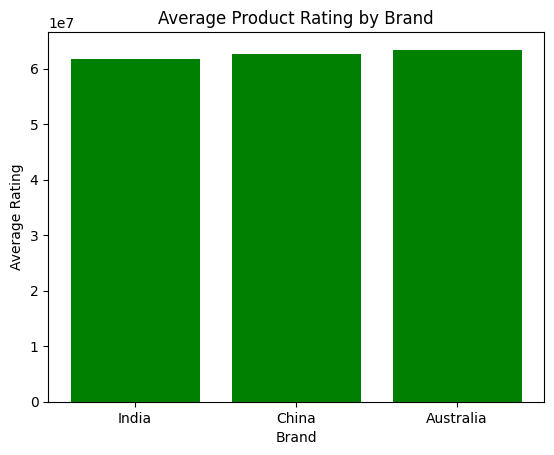

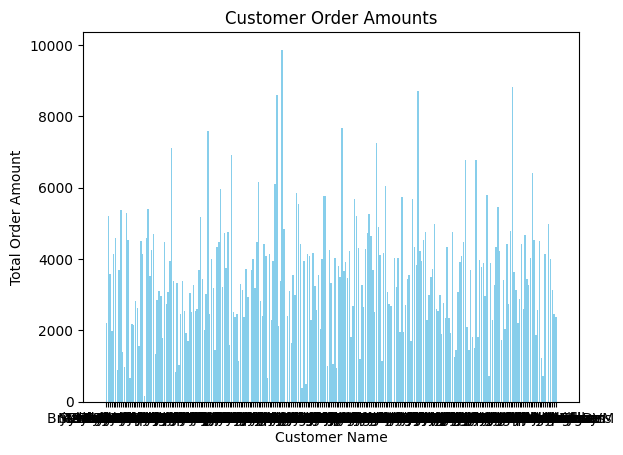